# Hp-DAC — Plot Standard

**Run the style cell. Then use matplotlib exactly as you always have.**

```python
fig, ax = plt.subplots()
ax.plot(x1, y1, ls="none", label="Series 1")   # navy circles, automatically
ax.plot(x2, y2, ls="none", label="Series 2")   # steel squares, automatically
ax.set_xlabel("Parameter 1 [SI]")
ax.set_ylabel("Parameter 2 [SI]")
ax.legend()
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="gray")
fig.savefig("figures/fig01.pdf", bbox_inches="tight")
```

Colours, markers, fonts, ticks, margins, size and export quality are already
correct. You never pass them, and there is nothing to import or call.

The palette is deliberately restrained: a navy-to-grey ramp with one rust
accent. These figures go into company reports and deliverables, not journal
papers, so the intent is a document that looks considered rather than
colourful. Series are separated mainly by **marker shape and dash pattern**;
colour is a secondary cue, which is also why the figures survive being
photocopied or printed in black and white.

**Two rules the style cannot enforce for you**

1. **Never abbreviate an axis label.** `Parameter 1 [SI]`, not `P1 [SI]`.
2. **Negative exponents, never a solidus.** `SI SI$^{-1}$`, not `SI/SI` —
   a solidus is ambiguous with two denominators (`W/m K` reads two ways).
   Write `r"Thermal conductivity [W m$^{-1}$ K$^{-1}$]"` with an `r` prefix.

## Requirements

Two packages. Both are almost certainly already installed.

| Package | Minimum | Why |
|---|---|---|
| `matplotlib` | 3.6 | The plots. 3.6 is where `legend(ncols=...)` appeared. |
| `numpy` | 1.24 | Only the example data; your own scripts may not need it. |

To run this notebook rather than a plain script, add `jupyterlab`.

```bash
pip install "matplotlib>=3.6" numpy jupyterlab
```

**The font is optional.** The style asks for Latin Modern Roman so figure
text matches a LaTeX document. If it is missing, matplotlib falls back to
DejaVu Serif silently — everything still runs, the figures just look slightly
different.

| System | Command |
|---|---|
| Debian / Ubuntu | `sudo apt install fonts-lmodern` |
| macOS | `brew install --cask font-latin-modern` |
| Windows | Install MiKTeX or TeX Live, or download from [GUST](https://www.gust.org.pl/projects/e-foundry/latin-modern) |

Run the next cell to check.

In [1]:
import matplotlib, numpy
import matplotlib.font_manager as fm

print("matplotlib", matplotlib.__version__)
print("numpy     ", numpy.__version__)

fonts = {f.name for f in fm.fontManager.ttflist}
print("font      ", "Latin Modern Roman found" if "Latin Modern Roman" in fonts
      else "Latin Modern Roman NOT found - falling back to DejaVu Serif")

matplotlib 3.10.1
numpy      2.3.4
font       Latin Modern Roman NOT found - falling back to DejaVu Serif


## The style cell

Copy this one cell into any notebook or script in the project. It is the
entire standard.

The line that does the work is `axes.prop_cycle`: colour, marker and dash
pattern are zipped together, so consecutive `ax.plot()` calls advance through
navy circles, steel squares, rust triangles, and so on, with no arguments.

In [2]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("figures", exist_ok=True)

# Formal palette: navy-to-grey ramp with a single rust accent.
COLORS = ["#14304A",   # 1 deep navy
          "#6C8FA8",   # 2 steel blue
          "#8C3A26",   # 3 rust        (accent - use sparingly)
          "#B4C0C8",   # 4 pale steel
          "#2C3E4C",   # 5 slate
          "#A39A6B",   # 6 olive
          "#767676",   # 7 mid grey
          "#000000"]   # 8 black
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
DASHES = ["-", "--", "-.", ":", (0, (5, 1, 1, 1)),
          (0, (3, 1, 3, 1)), (0, (1, 1)), (0, (7, 2))]

MM = 1 / 25.4          # millimetres to inches, for figsize

plt.rcParams.update({
    # --- series: colour, marker and dash advance together ---
    "axes.prop_cycle": (mpl.cycler(color=COLORS)
                        + mpl.cycler(marker=MARKERS)
                        + mpl.cycler(linestyle=DASHES)),
    "lines.markeredgecolor": "black",
    "lines.markeredgewidth": 1.0,
    "lines.markersize": 7.0,
    "lines.linewidth": 1.8,
    "scatter.edgecolors": "black",
    "errorbar.capsize": 3.0,

    # --- filled patches: histograms and bars ---
    "patch.force_edgecolor": True,
    "patch.edgecolor": "white",
    "patch.linewidth": 0.8,
    "hist.bins": "auto",

    # --- fonts ---
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.default": "regular",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    # --- axes frame ---
    "axes.linewidth": 1.4,
    "axes.edgecolor": "black",
    "axes.labelpad": 8.0,
    "axes.titlepad": 10.0,
    "axes.axisbelow": True,
    "axes.formatter.use_mathtext": True,
    "axes.formatter.limits": (-3, 4),

    # --- margins ---
    "axes.xmargin": 0.06,          # padding inside the axes
    "axes.ymargin": 0.09,
    "savefig.pad_inches": 0.08,    # border kept outside on save
    "figure.constrained_layout.use": True,
    "figure.constrained_layout.h_pad": 0.06,
    "figure.constrained_layout.w_pad": 0.06,

    # --- grid ---
    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.color": "black",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 1.0,

    # --- ticks ---
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 6.0, "ytick.major.size": 6.0,
    "xtick.minor.size": 3.0, "ytick.minor.size": 3.0,
    "xtick.major.width": 1.2, "ytick.major.width": 1.2,
    "xtick.minor.width": 0.8, "ytick.minor.width": 0.8,
    "xtick.major.pad": 6.0, "ytick.major.pad": 6.0,

    # --- legend ---
    "legend.frameon": True, "legend.framealpha": 1.0,
    "legend.edgecolor": "0.6", "legend.fancybox": False,
    "legend.borderpad": 0.5, "legend.labelspacing": 0.5,
    "legend.borderaxespad": 0.8,
    "legend.numpoints": 1, "legend.scatterpoints": 1,

    # --- size, layout and export quality ---
    "figure.figsize": (190 * MM, 120 * MM),    # full text width
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

## How the cycle behaves

| You write | You get |
|---|---|
| `ax.plot(x, y, ls="none")` | Markers only — **scatter** |
| `ax.plot(x, y, marker="none")` | Line only — **line plot** |
| `ax.plot(x, y)` | Both, joined markers |
| `ax.errorbar(x, y, yerr=e, ls="none")` | Marker and colour from the cycle |
| `ax.hist(x)` | Filled bars, white separators, automatic bins |
| `ax.scatter(x, y)` | Colour only; `scatter` ignores the marker cycle, so prefer `plot(..., ls="none")` |

To reuse an earlier series' colour — a model curve drawn over its own data —
name it: `ax.plot(xs, ys, color=COLORS[0], marker="none")`.

**Grid.** The major grid comes from the style cell. Add the minor grid after
plotting, one line per axes:

```python
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="gray")
```

### The palette

| # | Colour | Hex | Marker | Grey value |
|---|---|---|---|---|
| 1 | deep navy | `#14304A` | `o` | 49 |
| 2 | steel blue | `#6C8FA8` | `s` | 137 |
| 3 | rust | `#8C3A26` | `^` | 84 |
| 4 | pale steel | `#B4C0C8` | `D` | 188 |
| 5 | slate | `#2C3E4C` | `v` | 62 |
| 6 | olive | `#A39A6B` | `P` | 151 |
| 7 | mid grey | `#767676` | `X` | 117 |
| 8 | black | `#000000` | `*` | 0 |

The first four are at least 35 grey levels apart, so a black-and-white
printout stays readable. Rust is the only saturated colour: use it for the
series that carries the message, and leave the rest in the blue-grey range.

## Standard plot 1 — scatter

Measured points, one marker per observation, no connecting line. Use it when
the x values are samples rather than a continuous sweep.

**Rules.** Markers only (`ls="none"`); no line implying a trend that was not
measured. Four series is a comfortable maximum — beyond that use panels.

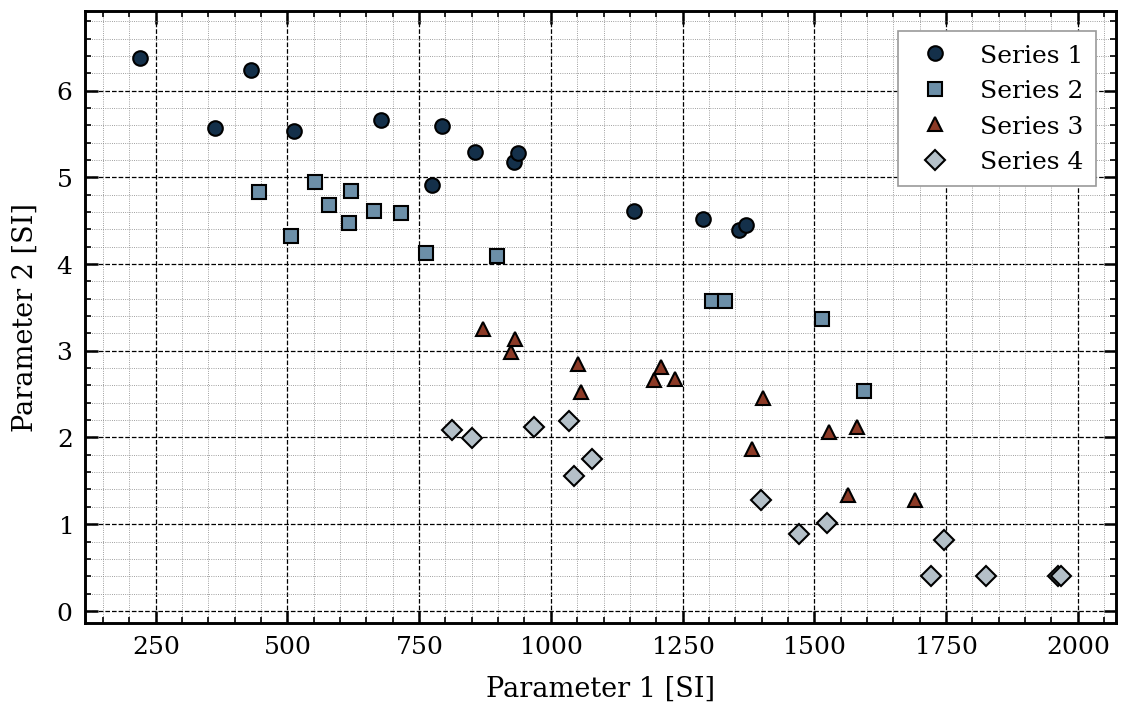

In [3]:
rng = np.random.default_rng(20260723)

scatter_data = {}
for i in range(4):
    x = np.sort(rng.uniform(200 + 200 * i, 1400 + 200 * i, 14))
    y = np.clip(5.4 - 1.0 * i - 1.6e-3 * (x - 700) + rng.normal(0, 0.25, x.size),
                0.4, None)
    scatter_data[f"Series {i + 1}"] = (x, y)

fig, ax = plt.subplots()
for label, (x, y) in scatter_data.items():
    ax.plot(x, y, ls="none", label=label)

ax.set_xlabel("Parameter 1 [SI]")
ax.set_ylabel("Parameter 2 [SI]")
ax.legend(loc="upper right")

ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="gray")
ax.grid(True, which="major", linestyle="--", linewidth=0.6, color="black")

fig.savefig("figures/standard_scatter.pdf", bbox_inches="tight")
fig.savefig("figures/standard_scatter.png", dpi=600, bbox_inches="tight")
plt.show()

## Standard plot 2 — line

Continuous behaviour: model output, a parametric sweep, a time series.

**Rules.** Lines only (`marker="none"`) — with 200 points, markers become a
smear. If the reader needs to see where the computed points lie, thin them
with `markevery=20` rather than dropping the marker cycle. Dash patterns
advance with colour, so the series stay distinguishable in a photocopy.

To overlay a model on its own measurements, plot the data first and name the
colour on the curve: `ax.plot(xs, ys, color=COLORS[i], marker="none")`.

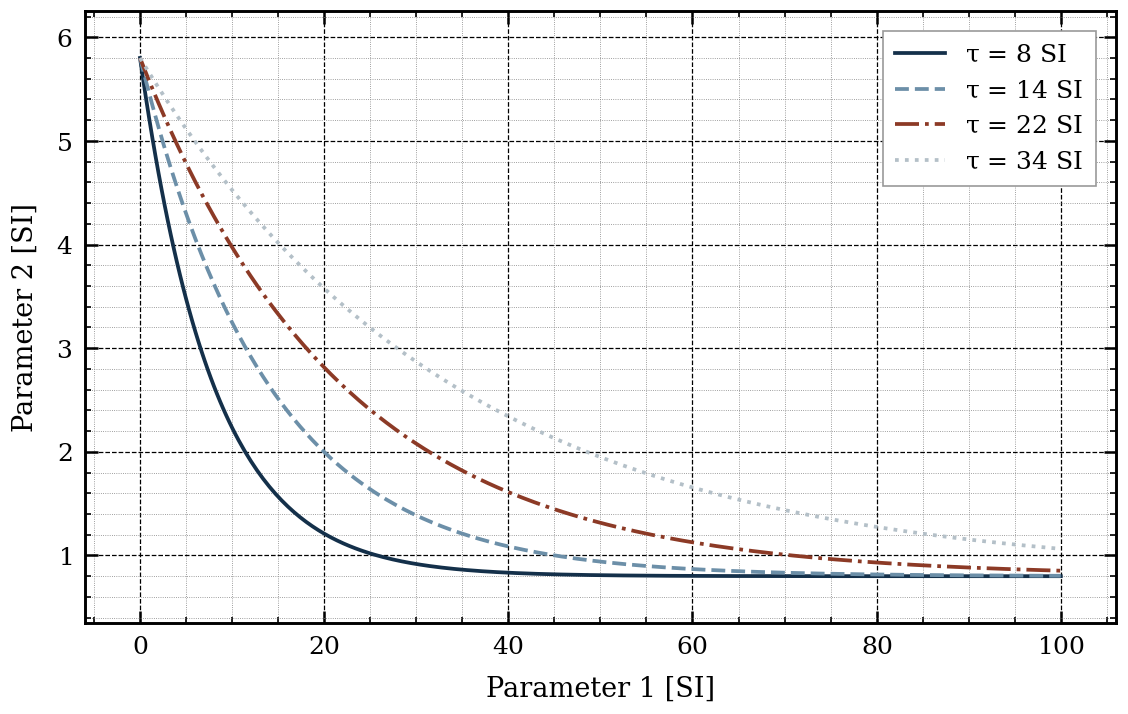

In [4]:
xs = np.linspace(0, 100, 300)

fig, ax = plt.subplots()
for i, tau in enumerate([8, 14, 22, 34]):
    ax.plot(xs, 5.0 * np.exp(-xs / tau) + 0.8, marker="none",
            label=rf"$\tau$ = {tau} SI")

ax.set_xlabel("Parameter 1 [SI]")
ax.set_ylabel("Parameter 2 [SI]")
ax.legend(loc="upper right")

ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="gray")
ax.grid(True, which="major", linestyle="--", linewidth=0.6, color="black")

fig.savefig("figures/standard_line.pdf", bbox_inches="tight")
fig.savefig("figures/standard_line.png", dpi=600, bbox_inches="tight")
plt.show()

## Standard plot 3 — histogram

Two cases, and they need different treatment.

**One distribution** — filled bars in navy with white separators. Add a
dashed reference line for the mean or the specification limit; a histogram
without a reference is hard to read against anything.

**Two or more distributions** — use `histtype="step"`, not translucent fills.
Overlapping alpha fills produce a muddy third colour that means nothing and
disappears entirely in greyscale; outlines stay readable at any number of
series.

**Bins.** `bins="auto"` is set in the style cell and is fine while exploring.
For a figure that goes into a report, pass **explicit edges** —
`bins=np.arange(0, 7.5, 0.5)` — so that re-running with one more data point
does not silently redraw the figure.

**Counts or density?** Counts when the samples are the same size, density
when they are not. Comparing raw counts of unequal samples is the most common
way a histogram misleads.

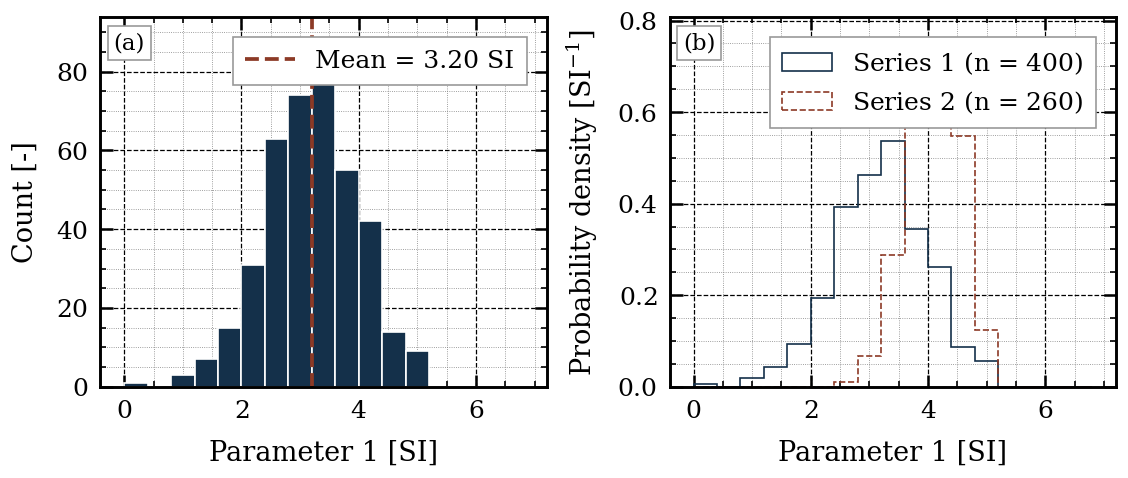

In [5]:
sample_a = rng.normal(3.2, 0.8, 400)
sample_b = rng.normal(4.1, 0.5, 260)

fig, axes = plt.subplots(1, 2, figsize=(190 * MM, 80 * MM))

# (a) one distribution: filled, with the mean marked
edges = np.arange(0.0, 7.0, 0.4)
axes[0].hist(sample_a, bins=edges, color=COLORS[0])
axes[0].axvline(sample_a.mean(), color=COLORS[2], linestyle="--", lw=1.8,
                marker="none", label=f"Mean = {sample_a.mean():.2f} SI")
axes[0].set_xlabel("Parameter 1 [SI]")
axes[0].set_ylabel("Count [-]")
axes[0].legend(loc="upper right")

# (b) two distributions: outlines, density because the samples differ in size
axes[1].hist(sample_a, bins=edges, density=True, histtype="step", lw=1.8,
             color=COLORS[0], label=f"Series 1 ($n$ = {sample_a.size})")
axes[1].hist(sample_b, bins=edges, density=True, histtype="step", lw=1.8,
             color=COLORS[2], linestyle="--",
             label=f"Series 2 ($n$ = {sample_b.size})")
axes[1].set_xlabel("Parameter 1 [SI]")
axes[1].set_ylabel("Probability density [SI$^{-1}$]")
axes[1].legend(loc="upper right")

for ax, tag in zip(axes, ["(a)", "(b)"]):
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="gray")
    ax.grid(True, which="major", linestyle="--", linewidth=0.6, color="black")
    ax.text(0.03, 0.96, tag, transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="square,pad=0.25", facecolor="white",
                      edgecolor="0.6", linewidth=0.8))

fig.savefig("figures/standard_histogram.pdf", bbox_inches="tight")
fig.savefig("figures/standard_histogram.png", dpi=600, bbox_inches="tight")
plt.show()